In [699]:
import pandas as pd
import numpy as np 
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [700]:
df = pd.read_csv("placement.csv")

In [701]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


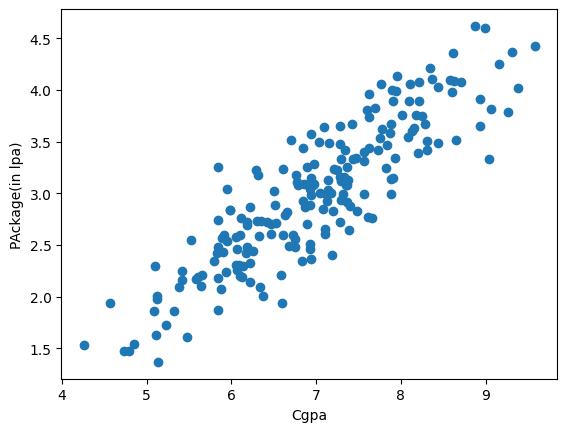

In [702]:
plt.scatter(df['cgpa'] , df['package'])
plt.xlabel("Cgpa")
plt.ylabel("PAckage(in lpa)")
plt.show()

In [703]:
x = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [704]:
y


0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [705]:
x_train , x_test, y_train , y_test =train_test_split(x ,y , test_size=0.2 , random_state=2)

In [706]:
lr = LinearRegression()

lr.fit(x_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [707]:
y_pred = lr.predict(x_test)

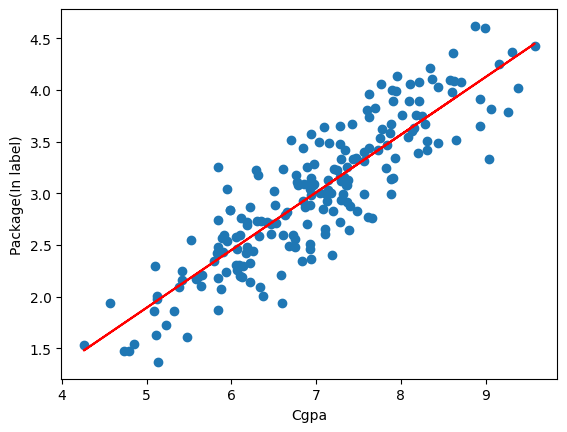

In [708]:
plt.scatter(df['cgpa'] , df['package'])
plt.plot(x_train , lr.predict(x_train) , color='red')
plt.xlabel('Cgpa')
plt.ylabel("Package(In label)")
plt.show()

# **Mean Absolute Error**

In [709]:
print("Mean Absolute Error" , mean_absolute_error(y_test , y_pred))

Mean Absolute Error 0.2884710931878175


# **Mean Square Error**

In [710]:
print("MEan Square Error" , mean_squared_error(y_test , y_pred))

MEan Square Error 0.12129235313495527


# **Root Mean Square Error**

In [711]:
print("Root Mean Square Error" , np.sqrt(mean_squared_error(y_test , y_pred)))

Root Mean Square Error 0.34827051717731616


# **R2 Score**

In [712]:
print('R2 Score' , r2_score(y_test , y_pred))

R2 Score 0.780730147510384


# **Adjusted R2 Score**

In [713]:
R2 = r2_score(y_test ,y_pred)

In [714]:
x_test.shape

(40, 1)

In [715]:
1 - ((1-R2) * (40-1) / (40-1-1)) # K =1 in our this case

0.7749598882343415

### **Adding Random column to see what changes occure in r2 and adjusted r2**

In [716]:
new_df = df.copy()
new_df['random'] = np.random.random(200)
new_df = new_df[['cgpa' , 'random' , 'package']]
new_df.head()

,cgpa,random,package
0,6.89,0.863275,3.26
1,5.12,0.068308,1.98
2,7.82,0.927287,3.25
3,7.42,0.708928,3.67
4,6.94,0.825040,3.57


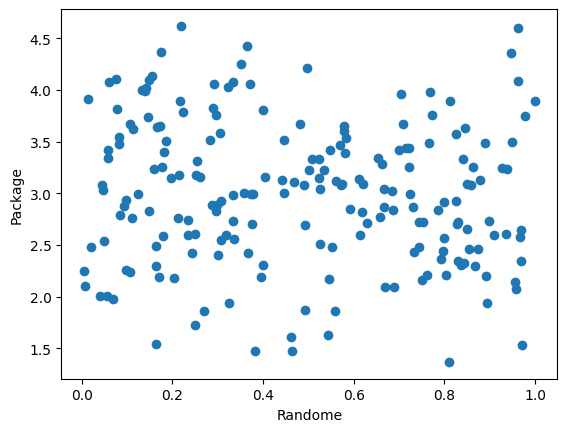

In [717]:
plt.scatter(new_df['random'],new_df['package'])
plt.xlabel("Randome")
plt.ylabel("Package")
plt.show()

In [718]:
x = new_df.iloc[:,0:2]
y = new_df.iloc[:,-1]

In [719]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2 , random_state=2)

In [720]:
lr = LinearRegression()

lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [721]:
y_pred = lr.predict(x_test)

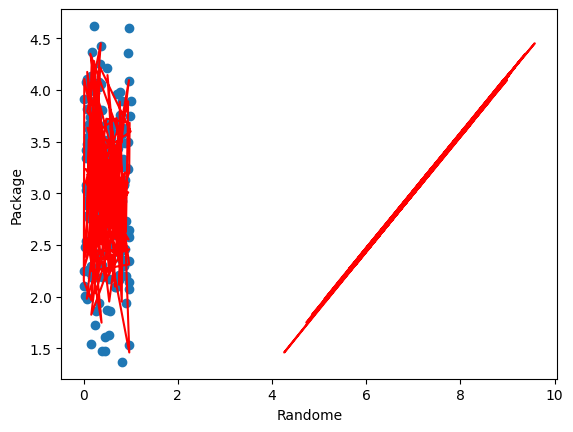

In [722]:
plt.scatter(new_df['random'],new_df['package'])
plt.plot(x_train , lr.predict(x_train) , color='red')
plt.xlabel("Randome")
plt.ylabel("Package")
plt.show()

In [723]:
print('R2 Score' , r2_score(y_test , y_pred))

R2 Score 0.7799161872170116


In [724]:
x_test.shape

(40, 2)

In [725]:
r2 = r2_score(y_test , y_pred)

print("Adjusted R2 Score" , 1 - ((1-r2)*(40-1) / (40-1-2)))

Adjusted R2 Score 0.7680197649044177


### **Adding Usefull column to see what changes occure in r2 and adjusted r2**

In [726]:
new_df1 = df.copy()
new_df1['IQ'] = new_df1['package'] + (np.random.randint(-12,12,200) / 10)
new_df1 = new_df1[['cgpa' , 'IQ' , 'package']]

new_df1.head()

,cgpa,IQ,package
0,6.89,4.36,3.26
1,5.12,1.68,1.98
2,7.82,2.25,3.25
3,7.42,3.47,3.67
4,6.94,2.57,3.57


In [727]:
x = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2 , random_state=2)
x

,cgpa,IQ
0,6.89,4.36
1,5.12,1.68
2,7.82,2.25
3,7.42,3.47
4,6.94,2.57
...,...,...
195,6.93,3.46
196,5.89,3.37
197,7.21,3.64
198,7.63,4.16


In [728]:
lr = LinearRegression()

lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)


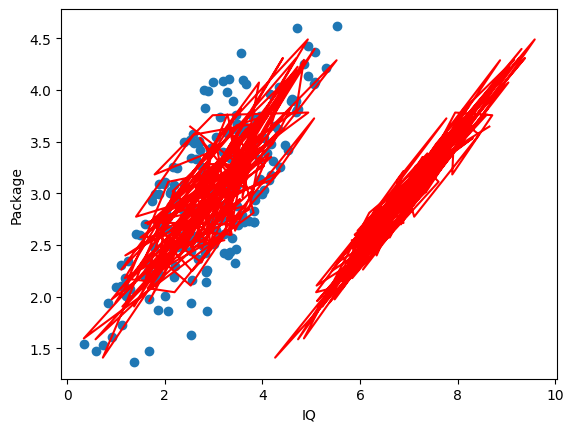

In [729]:
plt.scatter(new_df1['IQ'],new_df1['package'])
plt.plot(x_train , lr.predict(x_train) , color='red')
plt.xlabel("IQ")
plt.ylabel("Package")
plt.show()

In [730]:
print('R2 Score' , r2_score(y_test , y_pred))

R2 Score 0.8087492709164175


In [731]:
r21 = r2_score(y_test , y_pred)

print("Adjusted R2 Score" , 1 - ((1-r21)*(40-1) / (40-1-2)))

Adjusted R2 Score 0.7984113936686563
